# Sommaire :
 - <a href="#C1">Importation des données</a>
 
**Partie 2 : Nettoyez un jeu de données**
 - <a href="#C2">Nettoyez votre jeu de données</a>
 
**Partie 3 : Représentez vos variables**
 - <a href="#C3">Représentez la distribution empirique d'une variable</a>
 - <a href="#C4">Présentez une variable sous forme de tableau</a>
 - <a href="#C5">Identifions la cle premier de chaque table</a>
 - <a href="#C6"> fusionner nos 3 fichiers importe précédemment</a>
 - <a href="#C7">vérifieons ’il n’y a pas eu des erreurs de saisie dans certains prix des produits.</a>
 - <a href="#C8">Familiarisez-vous avec les mesures de concentration</a>
 
**Partie 4 : Réalisez une analyse **
 - <a href="#C09">Inter Quartile Range (IQR)e</a>
 - <a href="#C10">boîte à moustaches</a>
 - <a href="#C11">Score Z</a>
 - <a href="#C12">IQR (intervalle interquartile)</a>




In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import scipy.stats as st
import warnings
warnings.simplefilter("ignore")

In [142]:
import warnings
warnings.simplefilter("ignore")

print("The shape of the dataframe is: ", data.shape)

#### Dans un premier temps, importons les trois fichiers  :

La première mission va être de rassembler les deux dataframes erp et web en un gros dataframe  qui contiendra l'ensemble des informations de notre fichier !



In [143]:
erp = pd.read_excel("erp.xlsx")  
liaison  = pd.read_excel("liaison.xlsx")
web  = pd.read_excel("web.xlsx")

### Identifions la cle premier de chaque table

# erp

In [18]:
display(erp)


,product_id,onsale_web,price,stock_quantity,stock_status
0,3847,1,24.2,0,outofstock
1,3849,1,34.3,0,outofstock
2,3850,1,20.8,0,outofstock
3,4032,1,14.1,0,outofstock
4,4039,1,46.0,0,outofstock
...,...,...,...,...,...
820,7203,0,45.0,30,instock
821,7204,0,45.0,9,instock
822,7247,1,54.8,23,instock
823,7329,0,26.5,14,instock


On vérifie que la table ne contient aucun doublon avant de pouvoir déterminer la clé primaire, à savoir 'erp' : les 825 produit sont tous distincts.


In [102]:
def doublons(df): # Nombre de doublons dans la dataframe
    print(len(df) - len(df.drop_duplicates()), 'doublons')

doublons(erp)

0 doublons


In [2]:
def cle_primaire(df_cle): # Vérification de la clé primaire
  table_length = len(df_cle) - len(df_cle.drop_duplicates())
  if table_length == 0:
    print('Clé primaire (0 doublon)')
  else:
    print('Pas une clé primaire (', table_length, 'doublons )')


In [105]:
erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
dtypes: float64(1), int64(3), object(1)
memory usage: 32.4+ KB


Les variables ne contiennent aucune valeur manquant product_id' est la clé primaire : les produits sont uniques.

# web

In [144]:
display(web)

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,bon-cadeau-25-euros,0,0,0,0.0,10.0,taxable,NaN,1.0,2018-06-01 13:53:46,...,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1,15298,0,0,0,0.0,6.0,taxable,NaN,2.0,2018-02-08 12:58:52,...,pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,2019-12-30 08:30:29,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
2,15296,0,0,0,0.0,0.0,taxable,NaN,2.0,2018-02-08 13:49:41,...,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 09:00:17,2019-12-21 08:00:17,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,15300,0,0,0,0.0,0.0,taxable,NaN,2.0,2018-02-08 14:08:36,...,pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 18:15:03,2020-06-26 16:15:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
4,19814,0,0,0,0.0,3.0,taxable,NaN,2.0,2018-02-09 14:01:05,...,pierre-jean-villa-igp-gamine-2018,2020-01-04 16:36:01,2020-01-04 15:36:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,16135,0,0,0,0.0,5.0,NaN,NaN,2.0,2020-04-25 13:22:38,...,mouthes-le-bihan-aime-chai-2015,2020-08-26 17:35:03,2020-08-26 15:35:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1509,15891,0,0,0,0.0,0.0,NaN,NaN,2.0,2020-05-02 14:53:40,...,camin-larredya-jurancon-sec-la-virada-2018,2020-08-26 17:35:02,2020-08-26 15:35:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1510,15887,0,0,0,0.0,0.0,NaN,NaN,2.0,2020-05-02 15:00:54,...,jamet-cote-rotie-fructus-voluptas-2018,2020-08-14 18:15:03,2020-08-14 16:15:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1511,13127-1,0,0,0,0.0,0.0,NaN,NaN,2.0,2020-06-09 15:42:04,...,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0


In [145]:
doublons(web)

82 doublons


In [146]:
web.drop_duplicates(inplace=True) # Suppression des doublons
print(len(web), 'lignes après suppression des doublons') # Vérification du nombre de lignes

1431 lignes après suppression des doublons


In [147]:
cle_primaire(web['sku'])

Pas une clé primaire ( 716 doublons )


In [148]:
web1 = web.dropna(subset=['sku']) 

In [150]:
web["sku"].value_counts()

bon-cadeau-25-euros    2
14828                  2
14679                  2
15526                  2
16305                  2
                      ..
15145                  2
15801                  2
15452                  2
15038                  2
16230                  2
Name: sku, Length: 714, dtype: int64

Supprimons les doublons

In [151]:
web1 = web1.drop_duplicates(subset=['sku'])

In [152]:
web1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 714 entries, 0 to 798
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    714 non-null    object        
 1   virtual                714 non-null    int64         
 2   downloadable           714 non-null    int64         
 3   rating_count           714 non-null    int64         
 4   average_rating         714 non-null    float64       
 5   total_sales            714 non-null    float64       
 6   tax_status             714 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            714 non-null    float64       
 9   post_date              714 non-null    datetime64[ns]
 10  post_date_gmt          714 non-null    datetime64[ns]
 11  post_content           0 non-null      float64       
 12  post_title             714 non-null    object        
 13  post_

Là il n y a plus de doublon ni valeur manquante. 'sku' est la clé primaire 

# remarque

In [153]:
a = web.loc[web['sku'].isnull(),:]

In [117]:
post_namenot_nul = a.loc[a['post_name'].notnull(),:]
display(post_namenot_nul)

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
470,NaN,0,0,0,0.0,0.0,taxable,NaN,2.0,2018-07-31 12:07:23,...,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
471,NaN,0,0,0,0.0,0.0,taxable,NaN,2.0,2018-08-08 11:23:43,...,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


on peut remarquer qu il y a de lignes dans la colonne post_name  qui contient de valeurs non NA qui correspond a NA  dans les lignes du colonne sku

ceci est explique par l'effet que ces produits ne sont pas Encore mit en vente 

- L’export issu de la boutique en ligne contient le nombre de ventes pour chaque produit depuis sa mise en ligne, il ne permet pas d’analyser l'évolution des ventes dans le temps.




# liaison

In [155]:
# Renommage la colonne id_web de facon explicite et en (sku)
liaison.rename(columns={'id_web':'sku'},inplace=True)

In [156]:
display(liaison)

,product_id,sku
0,3847,15298
1,3849,15296
2,3850,15300
3,4032,19814
4,4039,19815
...,...,...
820,7203,NaN
821,7204,NaN
822,7247,13127-1
823,7329,14680-1


In [157]:
doublons(liaison)

0 doublons


In [158]:
cle_primaire(liaison['product_id'])

Clé primaire (0 doublon)


In [159]:
 liaison.loc[liaison['sku'].isnull(),:]

,product_id,sku
19,4055,NaN
49,4090,NaN
50,4092,NaN
119,4195,NaN
131,4209,NaN
...,...,...
817,7196,NaN
818,7200,NaN
819,7201,NaN
820,7203,NaN


In [160]:
print('on a ', len(liaison.loc[liaison['sku'].isnull(),:]), ' produits qui ne sont pas encore mit en vente en ligne' )

on a  91  produits qui ne sont pas encore mit en vente en ligne


 A présent, nous allons fusionner nos 3 fichiers  importe précédemment. . Vous pouvez nommer le dataframe final raproch :

In [161]:
raproc = liaison.merge(web1)

In [162]:
raprocfin = raproc.merge(erp)

In [163]:
display(raprocfin)

,product_id,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,...,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,onsale_web,price,stock_quantity,stock_status
0,3847,15298,0,0,0,0.0,6.0,taxable,NaN,2.0,...,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,1,24.2,0,outofstock
1,3849,15296,0,0,0,0.0,0.0,taxable,NaN,2.0,...,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,1,34.3,0,outofstock
2,3850,15300,0,0,0,0.0,0.0,taxable,NaN,2.0,...,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,1,20.8,0,outofstock
3,4032,19814,0,0,0,0.0,3.0,taxable,NaN,2.0,...,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,1,14.1,0,outofstock
4,4039,19815,0,0,0,0.0,0.0,taxable,NaN,2.0,...,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,1,46.0,0,outofstock
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,6930,16135,0,0,0,0.0,5.0,taxable,NaN,2.0,...,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,1,8.4,83,instock
710,7023,15891,0,0,0,0.0,0.0,taxable,NaN,2.0,...,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,1,27.5,15,instock
711,7025,15887,0,0,0,0.0,0.0,taxable,NaN,2.0,...,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,1,69.0,2,instock
712,7247,13127-1,0,0,0,0.0,0.0,taxable,NaN,2.0,...,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,1,54.8,23,instock


In [164]:
doublons(web1)

0 doublons


### 2  Deuxièmement, une fois le rapprochement effectué,  avoir le chiffre d’affaires par produit, ainsi que le total du chiffre d’affaires réalisé en ligne.

In [168]:
ciffre_d1 = raprocfin[['product_id','price','total_sales']]
display(ciffre_d1) 

,product_id,price,total_sales
0,3847,24.2,6.0
1,3849,34.3,0.0
2,3850,20.8,0.0
3,4032,14.1,3.0
4,4039,46.0,0.0
...,...,...,...
709,6930,8.4,5.0
710,7023,27.5,0.0
711,7025,69.0,0.0
712,7247,54.8,0.0


In [169]:
ciffre_d1['CA'] = ciffre_d1['total_sales']*ciffre_d1['price']
display(ciffre_d1)

,product_id,price,total_sales,CA
0,3847,24.2,6.0,145.2
1,3849,34.3,0.0,0.0
2,3850,20.8,0.0,0.0
3,4032,14.1,3.0,42.3
4,4039,46.0,0.0,0.0
...,...,...,...,...
709,6930,8.4,5.0,42.0
710,7023,27.5,0.0,0.0
711,7025,69.0,0.0,0.0
712,7247,54.8,0.0,0.0


In [170]:
print(' le total du chiffre d’affaires réalisé en ligne.est de',sum(ciffre_d1['CA']))

 le total du chiffre d’affaires réalisé en ligne.est de 70568.6


###  3 vérifieons ’il n’y a pas eu des erreurs de saisie dans certains prix des produits. 
 
 cette partie  effectuerai une analyse sur cette variable afin de détecter d’éventuelles valeurs aberrantes, de les lister et d’en faire une représentation graphique pour plus de lisibilité.

### Détecter les valeurs aberrantes

### Inter Quartile Range (IQR) 

on va utilisée la methode Inter Quartile Range (IQR) pour filtrer les valeurs aberrantes dans l ensemble de nos données. Les valeurs aberrantes sont des valeurs extrêmes qui sont loin des observations régulières qui peuvent éventuellement être générées en raison de la variabilité des mesures ou de l’erreur 

In [171]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('seaborn')

Maintenant, nous allons lire l’ensemble de données dans lequel nous voulons détecter et filtrer les valeurs aberrantes

In [172]:
erp.price.describe()

count    825.000000
mean      32.415636
std       26.795849
min        5.200000
25%       14.600000
50%       24.400000
75%       42.000000
max      225.000000
Name: price, dtype: float64

On peut observer que des caractéristiques telles que « price » prix, a  une valeur maximale très différée par rapport à la valeur de 75 %, nous pouvons donc dire qu’il y a certaines observations qui agissent comme des valeurs aberrantes dans l’ensemble de données.

Cela peut être vérifié en traçant une boîte à moustaches des caractéristiques ci-dessus, ici je trace la boîte à moustaches pour la colonne price.

### boîte à moustaches



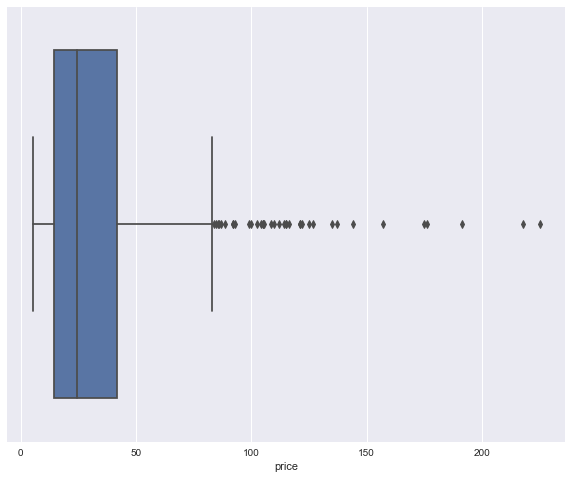

In [173]:
plt.figure(figsize=(10,8))
sns.boxplot(erp['price'])
plt.show()

On peut observer la présence de valeurs aberrantes au-delà du troisième quartile dans le box plot.

In [174]:
np.quantile(erp['price'], 0.75)

42.0

In [175]:
# la Position des Outlier
print(np.where(erp['price']>(np.quantile(erp['price'], 0.75))))

(array([  4,   8,   9,  10,  17,  18,  19,  32,  36,  41,  49,  50,  66,
        68,  71,  73,  74,  78,  79, 131, 132, 133, 135, 163, 190, 197,
       203, 205, 206, 207, 208, 209, 210, 211, 213, 214, 215, 216, 217,
       218, 219, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231,
       237, 238, 240, 242, 243, 244, 251, 253, 262, 263, 265, 268, 269,
       270, 272, 273, 274, 275, 276, 278, 279, 285, 289, 290, 291, 329,
       330, 383, 409, 410, 411, 413, 448, 456, 457, 458, 460, 461, 462,
       463, 464, 465, 466, 467, 474, 475, 476, 477, 480, 481, 482, 483,
       484, 485, 486, 487, 509, 518, 519, 520, 527, 528, 531, 532, 535,
       538, 541, 542, 543, 545, 550, 551, 555, 556, 559, 562, 563, 567,
       573, 581, 588, 589, 590, 593, 598, 626, 627, 628, 629, 631, 632,
       635, 644, 647, 650, 651, 652, 653, 654, 656, 657, 658, 659, 660,
       671, 672, 673, 675, 676, 692, 693, 694, 697, 701, 702, 703, 708,
       709, 710, 711, 712, 720, 722, 724, 729, 732, 733, 744, 7

In [176]:
len(erp.loc[erp["price"]>42]) 

206

 la liste de valeurs aberrantes

In [177]:
erp.loc[erp["price"]>42]

,product_id,onsale_web,price,stock_quantity,stock_status
4,4039,1,46.0,0,outofstock
8,4043,1,60.0,12,instock
9,4045,1,42.6,66,instock
10,4046,1,80.0,0,outofstock
17,4053,1,44.3,16,instock
...,...,...,...,...,...
811,7169,0,45.0,3,instock
812,7170,0,45.0,43,instock
820,7203,0,45.0,30,instock
821,7204,0,45.0,9,instock


fig, ax = plt.subplots(figsize = (18,10))
ax.scatter(erp['product_id'], erp['price'])
 z score 

Dans le graphique ci-dessus, on peut clairement voir que les valeurs supérieures à 95 agissent comme des valeurs aberrantes.

Le Z-Score est également appelé score standard. Cette valeur/score permet de comprendre à quelle distance se trouve le point de données de la moyenne. Et après avoir défini une valeur seuil, on peut utiliser les valeurs de score z des points de données pour définir les valeurs aberrantes.

### Score Z

In [178]:
from scipy import stats
import numpy as np

In [179]:
z = np.abs(stats.zscore(erp['price']))
print(z)

0      0.306787
1      0.070366
2      0.433749
3      0.683940
4      0.507265
         ...   
820    0.469923
821    0.469923
822    0.835874
823    0.220901
824    0.601788
Name: price, Length: 825, dtype: float64


In [180]:
[np.where(z > 3)]

[(array([208, 210, 227, 230, 242, 411, 460, 556, 598, 635, 651, 652, 697,
         703, 708, 709, 711, 712]),)]

In [181]:
b = np.where(z >3)


In [182]:
for i in b :
    display(erp.iloc[i])
print('avec cette methode on a detecte', len(erp.iloc[i]),'valeur aberante')

,product_id,onsale_web,price,stock_quantity,stock_status
208,4352,1,225.0,0,outofstock
210,4355,1,126.5,2,instock
227,4402,1,176.0,8,instock
230,4406,1,157.0,3,instock
242,4594,1,144.0,0,outofstock
411,4904,1,137.0,13,instock
460,5001,1,217.5,20,instock
556,5612,1,124.8,12,instock
598,5767,1,175.0,12,instock
635,5892,1,191.3,10,instock


avec cette methode on a detecte 18 valeur aberante


###  IQR (intervalle interquartile)
 
 IQR (intervalle interquartile)  est l’approche la plus couramment utilisée et la plus fiable utilisée dans le domaine de la recherche pour trouver les valeurs aberrantes.

In [183]:
Q1 = np.percentile(erp['price'], 25,
                   interpolation = 'midpoint')
 
Q3 = np.percentile(erp['price'], 75,
                   interpolation = 'midpoint')
IQR = Q3 - Q1

In [184]:
IQR

27.4

In [185]:
upper = erp['price'] >= (Q3+1.5*IQR)
 

print(np.where(upper))

# Below Lower bound


(array([ 19,  66,  68, 208, 210, 214, 227, 228, 230, 231, 240, 242, 410,
       411, 460, 465, 466, 475, 476, 486, 545, 551, 556, 598, 635, 650,
       651, 652, 697, 702, 703, 708, 709, 710, 711, 712, 724]),)


In [186]:
c = np.where(upper)

In [187]:
for i in c :
    display(erp.iloc[i])
print('avec cette methode on a detecte', len(erp.iloc[i]),'valeur aberante')

,product_id,onsale_web,price,stock_quantity,stock_status
19,4055,0,86.1,0,outofstock
66,4115,1,100.0,11,instock
68,4132,1,88.4,5,instock
208,4352,1,225.0,0,outofstock
210,4355,1,126.5,2,instock
214,4359,1,85.6,0,outofstock
227,4402,1,176.0,8,instock
228,4404,1,108.5,2,instock
230,4406,1,157.0,3,instock
231,4407,1,104.0,6,instock


avec cette methode on a detecte 37 valeur aberante


In [188]:
lower = erp['price'] <= (Q1-1.5*IQR)

print(np.where(lower))



(array([], dtype=int64),)


In [189]:
# Below Lower bound
lower = erp['price'] <= (Q1-1.5*IQR)
print("Lower bound:", lower)
print(np.where(lower))

Lower bound: 0      False
1      False
2      False
3      False
4      False
       ...  
820    False
821    False
822    False
823    False
824    False
Name: price, Length: 825, dtype: bool
(array([], dtype=int64),)


In [ ]:
raprocfin